In [ ]:
!pip install -q kaggle
import os
from google.colab import files
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Загрузите ваш файл kaggle.json:")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d warcoder/cats-vs-dogs-vs-birds-audio-classification
!unzip -q cats-vs-dogs-vs-birds-audio-classification.zip -d /content/dataset

Загрузите ваш файл kaggle.json:


Saving 00f0204f_nohash_2.wav to 00f0204f_nohash_2.wav
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/warcoder/cats-vs-dogs-vs-birds-audio-classification
License(s): Attribution 4.0 International (CC BY 4.0)
cats-vs-dogs-vs-birds-audio-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/dataset/Animals/bird/00b01445_nohash_0.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: Готово! Файлы находятся в папке /content/dataset


In [ ]:
import librosa
import IPython.display as ipd

file_path = '/content/00f0204f_nohash_2.wav'
y, sr = librosa.load(file_path, sr=None)
ipd.Audio(y, rate=sr)

print(f"Частота: {sr} ")
print(f"Общее количество точек в массиве (y): {len(y)}")
print(f"Длительность звука: {len(y)/sr:.2f} сек.")
print(f"Первые 5 значений временного ряда: {y[:5]}\n")

Частота: 16000 
Общее количество точек в массиве (y): 16000
Длительность звука: 1.00 сек.
Первые 5 значений временного ряда: [0.00027466 0.00024414 0.00045776 0.00073242 0.00015259]



In [ ]:
!pip install audiomentations

In [ ]:
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
import numpy as np

augment = Compose([
    AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.03, p=1.0),
    PitchShift(min_semitones=-4, max_semitones=4, p=1.0),
])

y_aug = augment(samples=y, sample_rate=sr)
print(f"Первое число было: {y[0]:.6f}, стало: {y_aug[0]:.6f}")

Первое число было: 0.000275, стало: 0.003714


In [ ]:
print("Оригинальный (чистый) звук:")
display(ipd.Audio(y, rate=sr))

print("Измененный (шумный) звук для обучения нейросети:")
display(ipd.Audio(y_aug, rate=sr))

Оригинальный (чистый) звук:


Измененный (шумный) звук для обучения нейросети:


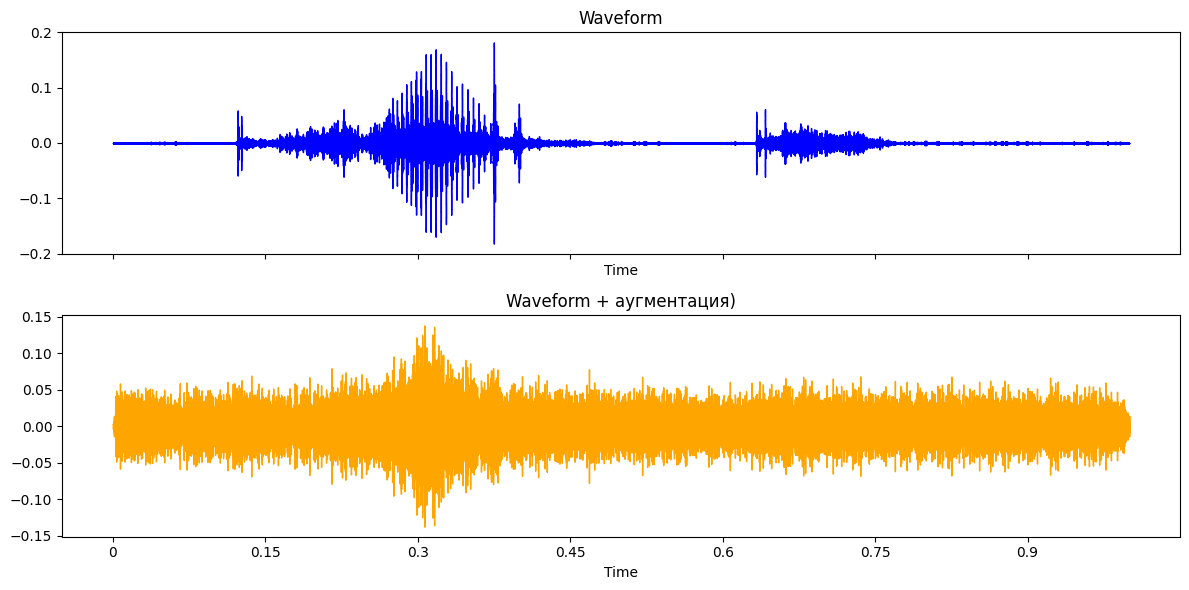

In [ ]:
# Waveform + аугментация
import matplotlib.pyplot as plt
import librosa.display
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(12, 6))
librosa.display.waveshow(y, sr=sr, ax=ax[0], color='blue')
ax[0].set(title='Waveform')
librosa.display.waveshow(y_aug, sr=sr, ax=ax[1], color='orange')
ax[1].set(title='Waveform + аугментация)')
plt.tight_layout()


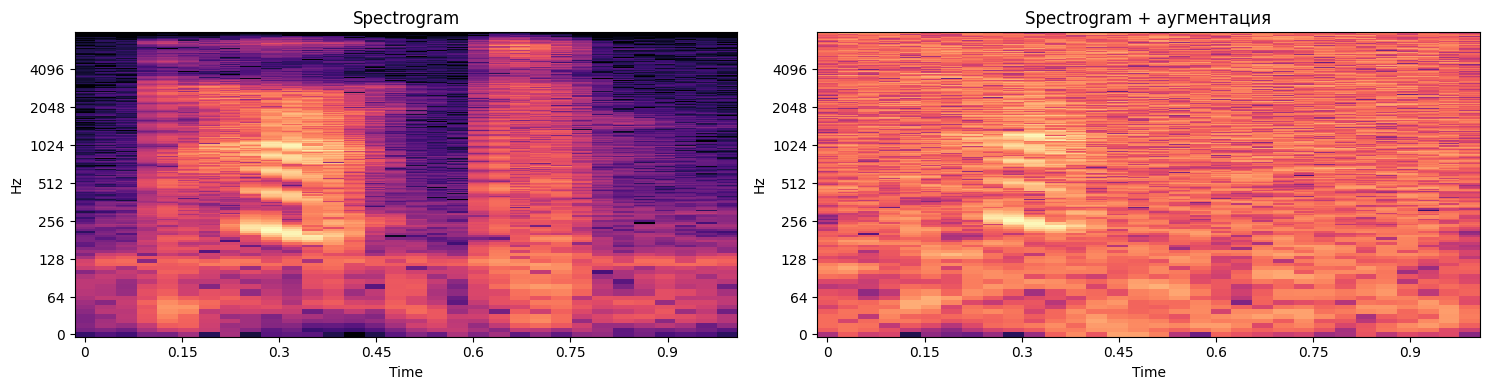

In [ ]:
# Spectrogram + аугментация
D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
D_aug = librosa.amplitude_to_db(np.abs(librosa.stft(y_aug)), ref=np.max)

fig, ax = plt.subplots(ncols=2, figsize=(15, 4))
img1 = librosa.display.specshow(D_clean, sr=sr, x_axis='time', y_axis='log', ax=ax[0])
ax[0].set(title='Spectrogram')
img2 = librosa.display.specshow(D_aug, sr=sr, x_axis='time', y_axis='log', ax=ax[1])
ax[1].set(title='Spectrogram + аугментация')
plt.tight_layout()


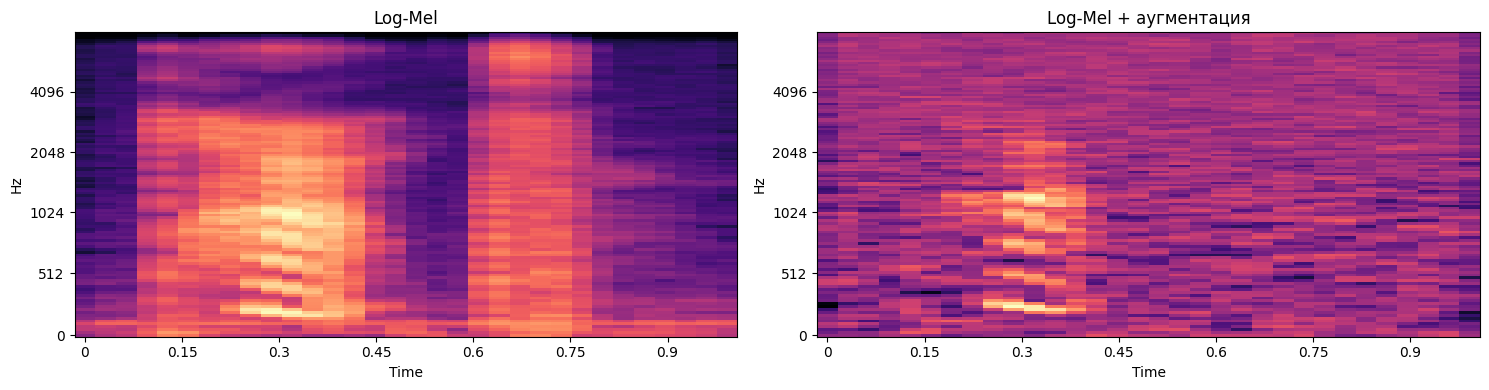

In [ ]:
# Log-Mel + аугментация
S_clean = librosa.feature.melspectrogram(y=y, sr=sr)
S_aug = librosa.feature.melspectrogram(y=y_aug, sr=sr)

fig, ax = plt.subplots(ncols=2, figsize=(15, 4))
librosa.display.specshow(librosa.power_to_db(S_clean), sr=sr, x_axis='time', y_axis='mel', ax=ax[0])
ax[0].set(title='Log-Mel')
librosa.display.specshow(librosa.power_to_db(S_aug), sr=sr, x_axis='time', y_axis='mel', ax=ax[1])
ax[1].set(title='Log-Mel + аугментация')
plt.tight_layout()


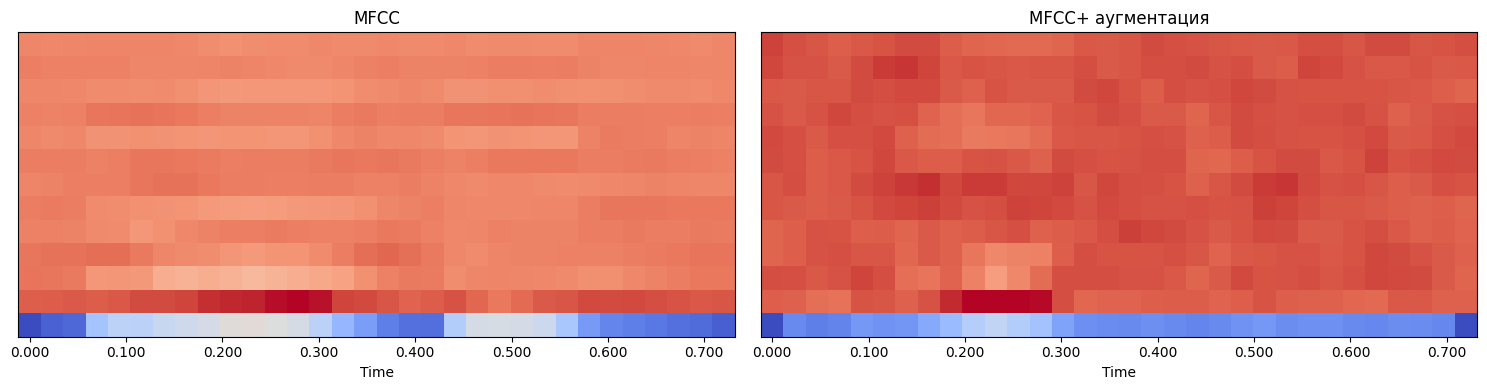

In [ ]:
# MFCC + аугментация
mfcc_clean = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
mfcc_aug = librosa.feature.mfcc(y=y_aug, sr=sr, n_mfcc=13)

fig, ax = plt.subplots(ncols=2, figsize=(15, 4))
img1 = librosa.display.specshow(mfcc_clean, x_axis='time', ax=ax[0])
ax[0].set(title='MFCC')
img2 = librosa.display.specshow(mfcc_aug, x_axis='time', ax=ax[1])
ax[1].set(title='MFCC+ аугментация')
plt.tight_layout()
plt.show()


In [ ]:
import zipfile
import os

zip_path = '/content/Animals.zip'
extract_path = '/content/animals_data'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Архив  распакован")
else:
    print("Файл не найден")


Архив  распакован


In [ ]:
import os
import librosa
import numpy as np
from audiomentations import Compose, AddGaussianNoise, PitchShift
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

augmenter = Compose([
    AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.03, p=1.0),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
])

def extract_mfcc(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)

In [ ]:
base_path = '/content/animals_data'
if 'Animals' in os.listdir(base_path): base_path = os.path.join(base_path, 'Animals')

X_clean, X_aug, y_labels = [], [], []

for label in os.listdir(base_path):
    folder = os.path.join(base_path, label)
    if not os.path.isdir(folder): continue

    for file in os.listdir(folder):
        if file.endswith('.wav'):
            path = os.path.join(folder, file)
            y, sr = librosa.load(path, duration=3)
            X_clean.append(extract_mfcc(y, sr))
            y_augmented = augmenter(samples=y, sample_rate=sr)
            X_aug.append(extract_mfcc(y_augmented, sr))
            y_labels.append(label)
X_clean, X_aug, y_labels = np.array(X_clean), np.array(X_aug), np.array(y_labels)


In [ ]:
X_train_c, X_test, y_train_c, y_test = train_test_split(X_clean, y_labels, test_size=0.2, random_state=42)
model_clean = RandomForestClassifier(n_estimators=100)
model_clean.fit(X_train_c, y_train_c)
acc_clean = accuracy_score(y_test, model_clean.predict(X_test))

In [ ]:
X_combined = np.vstack((X_clean, X_aug))
y_combined = np.hstack((y_labels, y_labels))
X_train_comb, _, y_train_comb, _ = train_test_split(X_combined, y_combined, test_size=0.1, random_state=42)

In [ ]:
model_aug = RandomForestClassifier(n_estimators=100)
model_aug.fit(X_train_comb, y_train_comb)
acc_combined = accuracy_score(y_test, model_aug.predict(X_test))

In [ ]:
print(f"Точность: {acc_clean:.2%}")
print(f"Точность с аугментацией: {acc_combined:.2%}")

Точность: 75.41%
Точность с аугментацией: 97.54%
